In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk
import recon_plot_helpers
from scipy.interpolate import CubicSpline

## 1. Load MoCo Image

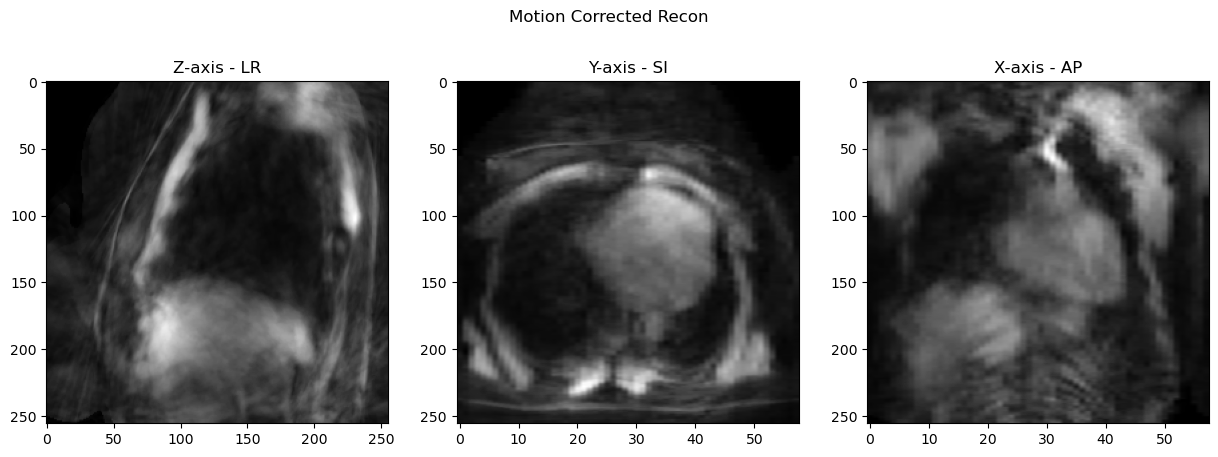

In [2]:
## Base directory where everything is located
base_dir = f"/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/new_coils/25sp/"

## Lambda = motion corrected image
lam_path = os.path.join(base_dir,"lam_fixed2.nii")
ref_img = sitk.GetArrayFromImage(sitk.ReadImage(lam_path))

# Extract center indices for plotting
z_idx = 44
y_idx = 128
# Plot at the center of the Liver ROI
fig, ax = recon_plot_helpers.plot_recons_all_axes(
    ref_img, 
    z_idx=z_idx, 
    y_idx=y_idx, 
    column_titles=True,
    title="Motion Corrected Recon"
)

## 2. Visualize interface coordinate

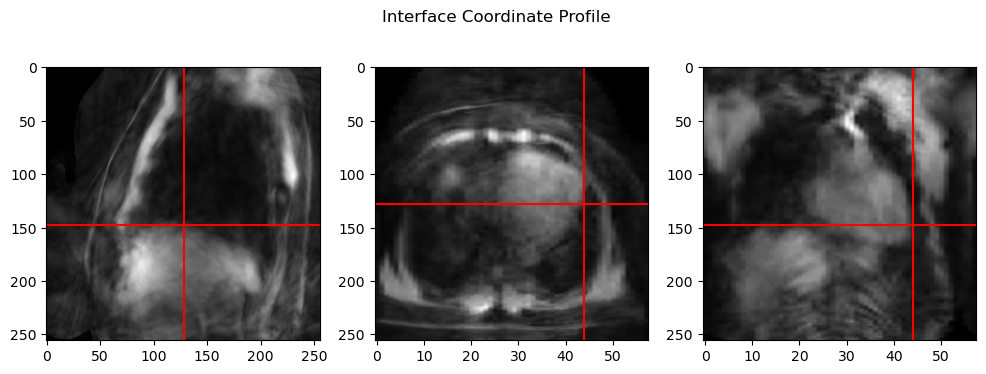

In [3]:
def visualize_interface_coord(ref_img, interface_coord):
    '''For a selected 3D interface coordinate, plot the intersecting lines on 3d slices
    ref_img: ndarray, (Nz, Ny, Nx)
        MRI image
    interface_coord: tuple (zi, yi, xi)
        Coordinate to plot
    
    '''
    ## Get image dimensons
    Nz, Ny, Nx = ref_img.shape

    ## 1. Convert grayscale to RGB for colored overlays
    vis_img = np.stack([ref_img]*3, axis=-1)  # shape: (Z, Y, X, 3)

    # Interface coordinates
    z_i, y_i, x_i = interface_coord

    # Set red intensity (255 if uint8; or max_val for float data) for each line profile
    red_val = vis_img.max()
    vis_img[:, y_i, x_i, 0] = red_val 
    vis_img[z_i, :, x_i, 0] = red_val
    vis_img[z_i, y_i, :, 0] = red_val

    fig, axs = plt.subplots(1, 3, figsize=(12,4))

    # Axial (XY at Z = z_i)
    axs[0].imshow(np.fliplr(ref_img[z_i]), cmap="gray")
    axs[0].axhline(y_i, color="red")
    axs[0].axvline(x_i, color="red")

    # Coronal (XZ at Y = y_i)
    axs[1].imshow(np.fliplr(np.rot90(ref_img[:, y_i, :],k=-3)), cmap="gray", aspect=Nz/Nx)
    axs[1].axhline(x_i, color="red")
    axs[1].axvline(z_i, color="red")

    # Sagittal (YZ at X = x_i)
    axs[2].imshow(np.rot90(ref_img[:, :, x_i], k=-1), cmap="gray", aspect=Nz/Ny)
    axs[2].axhline(y_i, color="red")
    axs[2].axvline(z_i, color="red")

    plt.suptitle("Interface Coordinate Profile")
    plt.show()

interface_heart = (44, 148, 128)
visualize_interface_coord(ref_img, interface_heart)

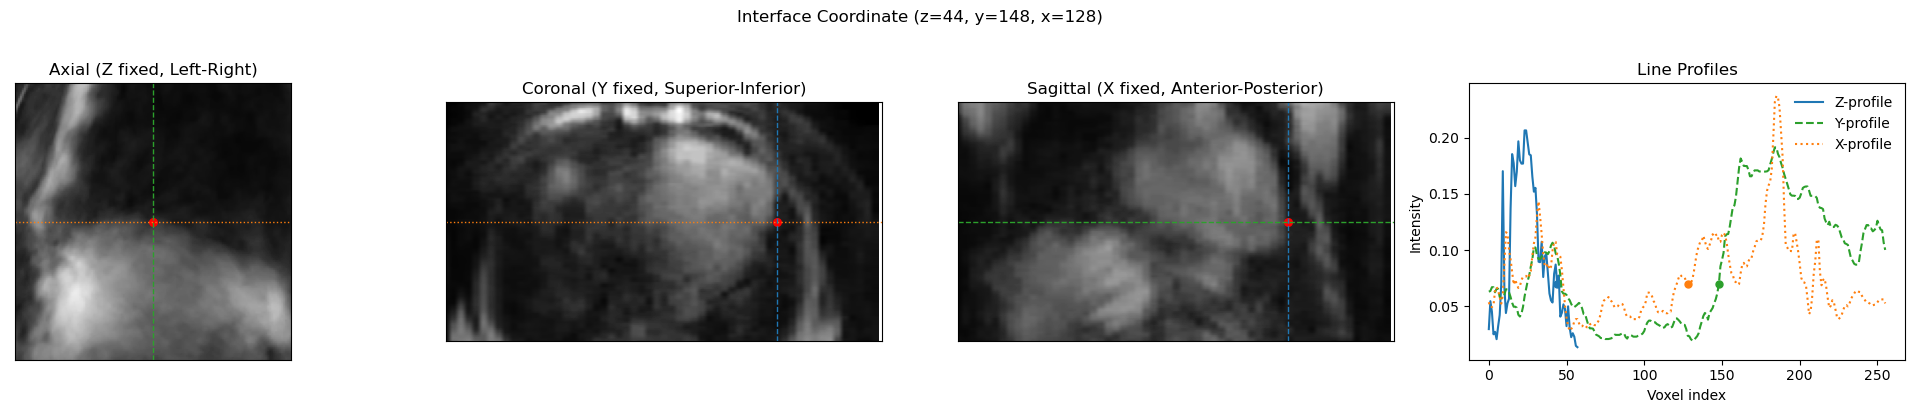

In [4]:
def interface_coord_with_profiles_clean(ref_img, interface_coord, zoom=40):
    """
    Visualization of orthogonal slices and line profiles

    Parameters
    ----------
    ref_img : 3D numpy array (Nz, Ny, Nx)
    interface_coord : tuple (z, y, x)
    zoom : int or None
        Shows a zoomed-in window (+/- zoom voxels) around the point.
    """
    Nz, Ny, Nx = ref_img.shape
    z_i, y_i, x_i = interface_coord

    ## Set colors to be consistent everywhere
    c_z = "tab:blue"
    c_y = "tab:green"
    c_x = "tab:orange"
    c_pt = "red"

    fig, axs = plt.subplots(1, 4, figsize=(20, 4))

    # ----------- AXIAL (XY at Z = z_i) ----------------
    img_xy = np.fliplr(ref_img[z_i])
    axs[0].imshow(img_xy, cmap="gray")

    ## Crosshair lines where profiles are
    axs[0].axhline(y_i, color=c_x, linestyle=":", linewidth=1)  # X-profile
    axs[0].axvline(x_i, color=c_y, linestyle="--", linewidth=1) # Y-profile

    ## Intersection point
    axs[0].scatter(x_i, y_i, color=c_pt, s=30)

    axs[0].set_title("Axial (Z fixed, Left-Right)")

    ## ---------------- CORONAL (XZ at Y = y_i) ----------------
    img_xz = np.fliplr(np.rot90(ref_img[:, y_i, :], k=-3))
    axs[1].imshow(img_xz, cmap="gray", aspect=Nz/Nx)

    axs[1].axhline(x_i, color=c_x, linestyle=":", linewidth=1)  # X-profile
    axs[1].axvline(z_i, color=c_z, linestyle="--", linewidth=1) # Z-profile

    axs[1].scatter(z_i, x_i, color=c_pt, s=30)

    axs[1].set_title("Coronal (Y fixed, Superior-Inferior)")

    ## --------------- SAGGITAL (YZ at X = x_i) ----------------
    img_yz = np.rot90(ref_img[:, :, x_i], k=-1)
    axs[2].imshow(img_yz, cmap="gray", aspect=Nz/Ny)

    axs[2].axhline(y_i, color=c_y, linestyle="--", linewidth=1) # Y-profile
    axs[2].axvline(z_i, color=c_z, linestyle="--", linewidth=1) # Z-profile

    axs[2].scatter(z_i, y_i, color=c_pt, s=30)

    axs[2].set_title("Sagittal (X fixed, Anterior-Posterior)")

    ## ------------ PROFILES --------------------------------
    profile_z = ref_img[:, y_i, x_i]
    profile_y = ref_img[z_i, :, x_i]
    profile_x = ref_img[z_i, y_i, :]

    axs[3].plot(profile_z, color=c_z, label="Z-profile")
    axs[3].plot(profile_y, color=c_y, linestyle="--", label="Y-profile")
    axs[3].plot(profile_x, color=c_x, linestyle=":", label="X-profile")

    ## Mark the crosshair intersection
    axs[3].scatter(z_i, profile_z[z_i], color=c_z, s=25)
    axs[3].scatter(y_i, profile_y[y_i], color=c_y, s=25)
    axs[3].scatter(x_i, profile_x[x_i], color=c_x, s=25)

    axs[3].set_xlabel("Voxel index")
    axs[3].set_ylabel("Intensity")
    axs[3].set_title("Line Profiles")
    axs[3].legend(frameon=False)

    ##If zoom set to int, zoom around these voxels
    if zoom is not None:
        def set_zoom(ax, cx, cy, max_x, max_y):
            ax.set_xlim(max(cx - zoom, 0), min(cx + zoom, max_x))
            ax.set_ylim(min(cy + zoom, max_y), max(cy - zoom, 0))

        set_zoom(axs[0], x_i, y_i, Nx, Ny)
        set_zoom(axs[1], z_i, x_i, Nz, Nx)
        set_zoom(axs[2], z_i, y_i, Nz, Ny)

    ## Only set ticks for graph
    for ax in axs[:3]:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(f"Interface Coordinate (z={z_i}, y={y_i}, x={x_i})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


interface_coord_with_profiles_clean(ref_img=ref_img, interface_coord=interface_heart, zoom=70)

### Decide on which line profile to use
- Use Superior-Inferior direction (Y Profile) since that is axis along which most breathing occurs during respiration

In [5]:
z_i, y_i, x_i = interface_heart
profile_si = ref_img[z_i, :, x_i]
print(f'profile_si.shape = {profile_si.shape}')

profile_si.shape = (256,)


## 3. Find line profile min, max

To find robust bounds for min/max, I use a Gaussian KDE. This estimates a continuous estimate of the distribution of intensity points in our line profile. Doing this to find two dominant peaks (signal vs no signal in SI plane) such that we can determine min/max without incorporating random noise spikes.

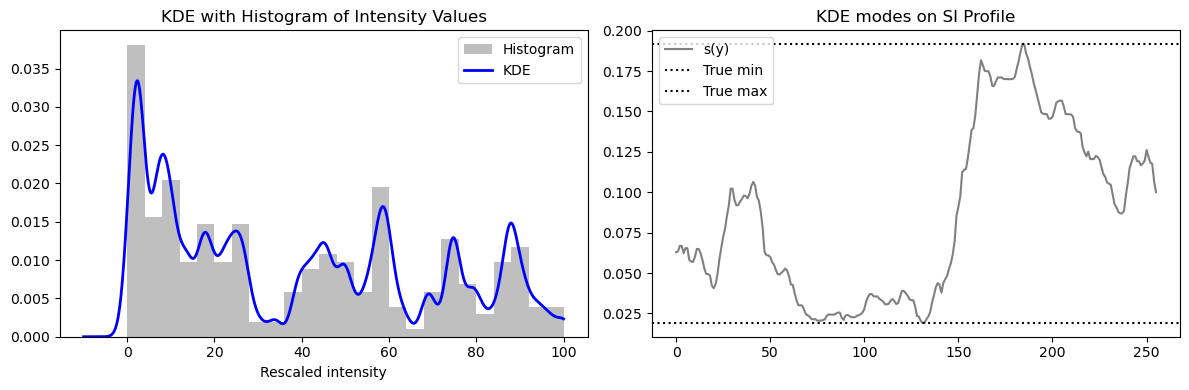

Final calculated s_min, s_max = (0.023211486893403042, 0.17093055870633822)
From percentiles: s_min_percentile, s_max_percentile = (0.026167578995227814, 0.15249091014266014)


In [8]:
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

def validate_kde_visual(profile, rescaled, x_range, density, bw_method, bins=25):
    '''Helper to visualize the Gaussian KDE'''
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ## overlay KDE on histogram
    axes[0].hist(rescaled, bins=bins, density=True, color='gray', 
                 alpha=0.5, label='Histogram')
    axes[0].plot(x_range, density, color='blue', lw=2, label='KDE')
    axes[0].set_title('KDE with Histogram of Intensity Values')
    axes[0].set_xlabel('Rescaled intensity')
    axes[0].legend()

    ## profile with found min/max overlaid
    axes[1].plot(profile, color='gray', label='s(y)')
    axes[1].axhline(profile.min(), color='black', linestyle=':', label='True min')
    axes[1].axhline(profile.max(), color='black', linestyle=':', label='True max')
    axes[1].set_title('KDE modes on SI Profile')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def compute_gaussian_kde(line_profile, bw_method, plot):
    '''Helper to compute Gaussian KDE
    Inputs
    -----------------
    line_profile: 1D ndarray
        Intensity values along 1 dimension
    bw_method: float
        Bandwidth factor for KDE, larger=more smoothing/less precise, smaller=more precise
    plot: bool (optional)
        Plot KDE overlaid on historgram

    Outputs
    -------------------
    x_range: ndarray
        1D array of values on which PDF is evaluated
    density: ndarray
        PDF
    '''
    ## 1. Rescale intensity values from 0-100
    rescaled = 100*(line_profile-line_profile.min())/(line_profile.max() - line_profile.min() + 1e-8)

    ## 2. Gaussian kernel density estimation
    kde = gaussian_kde(rescaled, bw_method=bw_method)

    ## 3. Initialize values on which to evaluate PDF 
    x_range = np.linspace(-10, 100, 1000)       ## 1000 points
    density = kde(x_range)                      ## Evaluate PDF

    ## Plot for validation
    if plot:
        validate_kde_visual(line_profile, rescaled, x_range, density, bw_method)
    return x_range, density

def find_min_max_kde(line_profile, peaks, x_range, density):
    '''Find modes of line profile using KDE and re-scale min and max
    Inputs
    -----------------
    line_profile: 1D ndarray
        Intensity values along 1 dimension
    peaks: ndarray
        Indices of peaks in density
    x_range: ndarray
        PDF axis points
    density: ndarray
        PDF from evaluating KDE

    Outputs
    -------------------
    s_min, s_max: float
        Min and max of line_profile
    '''
    ## 1. From indices of peaks, find peak values of PDF
    best_peaks = peaks[np.argsort(density[peaks])][-2:]
    mode_indices = sorted(best_peaks)
    min_val = x_range[mode_indices[0]]
    max_val = x_range[mode_indices[1]]

    ## 2. Re-scale min and max
    s_min = line_profile.min() + (min_val/100) * (line_profile.max() - line_profile.min())
    s_max = line_profile.min() + (max_val/100) * (line_profile.max() - line_profile.min())
    
    return s_min, s_max

def smooth_min_max(line_profile, bw_method=0.05, plot=True):
    '''Determine min/max of 1D signal using Gaussian KDE to smooth distribution of voxels/smooth any noise spikes.

    Inputs
    -----------------
    line_profile: 1D ndarray
        Intensity values along 1 dimension
    bw_method: float
        Bandwidth factor for KDE, larger=more smoothing/less precise, smaller=more precise
    plot: bool (optional)
        Plot KDE overlaid on historgram

    Outputs
    ------------------------------------
    (s_min, s_max): tuple
        Min and max after smoothing
    '''
    ## 1. Compute KDE and evaluate estimated PDF on a set of 1000 points
    x_range, density = compute_gaussian_kde(line_profile, bw_method=bw_method, plot=plot)

    ## 2. Find peaks of this PDF
    peaks, _ = find_peaks(density, distance=700)
    
    ## With peaks, select min and max representing modes
    if len(peaks) >= 2:
        s_min, s_max = find_min_max_kde(line_profile, peaks=peaks, 
                                        x_range=x_range, density=density)
    else:
        ## If no peaks detected, use percentile
        s_min = np.percentile(line_profile, 15)
        s_max = np.percentile(line_profile, 85)
    return (s_min, s_max)


s_min, s_max = smooth_min_max(profile_si)
print(f'Final calculated s_min, s_max = {s_min, s_max}')


## Percentiles for comparison
s_min_percentile = np.percentile(profile_si, 15)
s_max_percentile = np.percentile(profile_si, 85)
print(f'From percentiles: s_min_percentile, s_max_percentile = {s_min_percentile, s_max_percentile}')

Plot histogram with new min and max to visualize

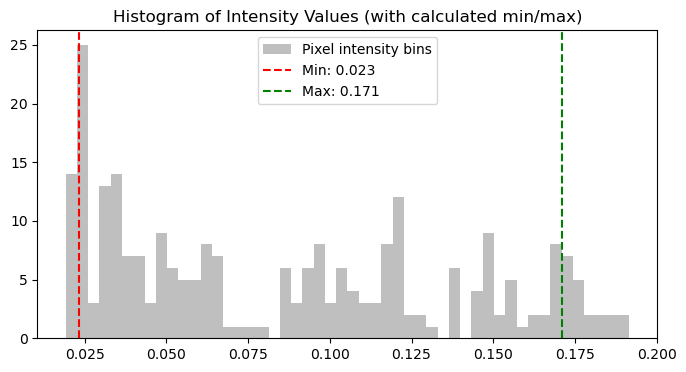

In [9]:
def plot_line_profile_hist(line_profile, s_min, s_max, bins=50):
    '''Plot histogram of intensity values for line profile'''
    plt.figure(figsize=(8, 4))
    plt.hist(line_profile, bins=bins, color='gray', alpha=0.5, label='Pixel intensity bins')
    plt.axvline(s_min, color='red', linestyle='--', label=f'Min: {s_min:.3f}')
    plt.axvline(s_max, color='green', linestyle='--', label=f'Max: {s_max:.3f}')
    plt.title(f"Histogram of Intensity Values (with calculated min/max)")
    plt.legend()
    plt.show()

plot_line_profile_hist(profile_si, s_min, s_max)

### 4. Gaussian smoothing + Interpolation for profile

In [10]:
from scipy.interpolate import CubicSpline

def interpolate_line_profile(line_profile, voxel_size, num_pts=1000):
    '''Interpolate line profile using cubic spline 
    Inputs
    -----------------
    line_profile: 1D ndarray
        Intensity values along 1 dimension
    voxel_size: float
        Voxel size in mm
    num_pts: int (optional)
        Number of pts to interpolate to

    Outputs
    ------------------------------------
    profile_interp : 1D ndarray, size = (num_pts,)
        Interpolated line profile
    
    '''
    ## 1. Define original coordinates
    coord_max_mm = len(line_profile)*voxel_size
    print(f'coord_max_mm = {coord_max_mm}')
    coord_original = np.linspace(0, coord_max_mm - 1, len(line_profile))
    # print(coord_original[:100])
    
    ## Interpolate with CubicSpline
    cubic_spline = CubicSpline(coord_original, line_profile)

    # 3. Generate the 1000-point smooth profile
    coord_axis_fine = np.linspace(0, coord_max_mm, num_pts)
    profile_interp = cubic_spline(coord_axis_fine)

    return profile_interp

def gaussian_filter(line_profile, sigma=1.0):
    '''Apply 1D Gaussian filter to 1D line profile'''
    line_profile_smoothed = gaussian_filter1d(line_profile, sigma=sigma)
    return line_profile_smoothed


profile_si_smoothed = gaussian_filter(profile_si, sigma=2.0)
profile_si_interp = interpolate_line_profile(profile_si_smoothed, voxel_size=1.172)

coord_max_mm = 300.032


### 5. Find the new center index in the 1000-point array

### 6.  HWHM Calculation

In [11]:
def find_hwhm(line_profile_interp, s_min, s_max, voxel_size, zoom_idx=None):

    ## 1. Zoom in on ROI for line profile 
    if zoom_idx is not None:
        line_profile_final = line_profile_interp[zoom_idx[0]:zoom_idx[1]]
    else:
        line_profile_final = line_profile_interp

    ## 2. Calculate threshold for half of maximum value
    threshold = (s_min + s_max) / 2.0
    # print(f'threshold = {threshold}')

    ## 2a. Calculate index for which threshold occurs
    profile_center_idx = np.argmin(np.abs(line_profile_final - threshold))

    ## 3. Calculate gradient of line profile (Line Spread Function?)
    gradient = np.abs(np.gradient(line_profile_final))
    # plt.plot(profile_si_interp)
    # plt.plot(gradient)
    # plt.title("Interpolated and smoothed SI Profile")
    # plt.show()

    ## 4. Find maximum value of LSF and get array index
    peak_idx = np.argmax(gradient)
    max_val = gradient[peak_idx]

    ## 4a. Find half of maximum for gradient
    half_max = max_val / 2.0


    ## 5. Find the indices where the gradient is above half_max
    idx_above_half_max = np.where(gradient >= half_max)[0]
    # print(f'idx_above_half_max = {idx_above_half_max}')

    ## 6. Calculate FWHM and HWHM in pixels
    fwhm_px = idx_above_half_max[-1] - idx_above_half_max[0]
    hwhm_px = fwhm_px / 2.0

    ## Convert to mm using the provided spacing for that axis
    hwhm_mm = hwhm_px * 1.172
    print(f'hwhm_mm = {hwhm_mm}')
    sharpness = 1.0/hwhm_mm

    return line_profile_final, threshold, profile_center_idx, gradient, half_max, hwhm_mm


line_profile_final, threshold, profile_center_idx, gradient, half_max, hwhm_mm = find_hwhm(profile_si_interp, s_min=s_min, s_max=s_max, voxel_size=1.172, zoom_idx=[400,800])

hwhm_mm = 106.06599999999999


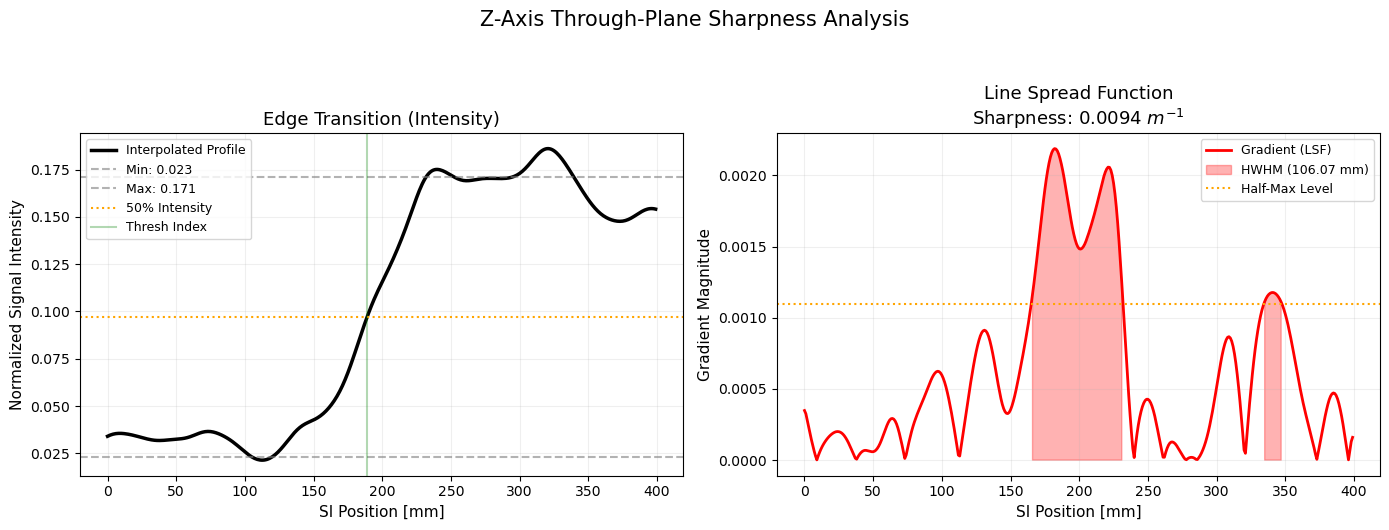

In [12]:
def plot_hwhm_analysis(profile_si, threshold, gradient, profile_center_idx, half_max, hwhm_mm, val_min, val_max):

    # Initialize Side-by-Side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
    
    # --- LEFT PLOT: Intensity Profile (Edge Transition) ---
    ax1.plot(profile_si, color='black', linewidth=2.5, label='Interpolated Profile')
    ax1.axhline(val_min, color='gray', linestyle='--', alpha=0.6, label=f'Min: {val_min:.3f}')
    ax1.axhline(val_max, color='gray', linestyle='--', alpha=0.6, label=f'Max: {val_max:.3f}')
    ax1.axhline(threshold, color='orange', linestyle=':', label='50% Intensity')
    ax1.axvline(profile_center_idx, color='green', linestyle='-', alpha=0.3, label='Thresh Index')
    
    ax1.set_title("Edge Transition (Intensity)", fontsize=13)
    ax1.set_ylabel('Normalized Signal Intensity', fontsize=11)
    ax1.set_xlabel('SI Position [mm]', fontsize=11)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.2)

    # --- RIGHT PLOT: Line Spread Function (Gradient) ---
    axis_fine = np.linspace(0, len(gradient)-1, len(gradient))
    ax2.plot(gradient, color='red', linewidth=2, label='Gradient (LSF)')
    # ax2.fill_between(axis_fine, 0, gradient, color='red', alpha=0.1)
    ax2.fill_between(range(len(gradient)), 0, gradient, where=(gradient >= half_max), 
                         color='red', alpha=0.3, label=f'HWHM ({hwhm_mm:.2f} mm)')
    ax2.axhline(half_max, color='orange', linestyle=':', label='Half-Max Level')
    
    ax2.set_title(f"Line Spread Function\nSharpness: {1/hwhm_mm:.4f} $m^{{-1}}$", fontsize=13)
    ax2.set_ylabel('Gradient Magnitude', fontsize=11)
    ax2.set_xlabel('SI Position [mm]', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.2)

    plt.suptitle(f"Z-Axis Through-Plane Sharpness Analysis", fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()


plot_hwhm_analysis(line_profile_final, threshold, gradient, profile_center_idx, half_max, hwhm_mm, s_min, s_max)